# Running my postive and negative controls on the expanded 6 FOVs (~400,000 transcripts)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import time

%run 03_K_function.ipynb

In [12]:

expanded_data = pd.read_parquet("../data/processed/s1_all_strips.parquet")
print(f"Total transcripts: {len(expanded_data['target'])}")

Total transcripts: 400238


In [13]:
GENE_A = 'KRT8'
GENE_B = 'KRT18'
R_MAX = 250           
N_R = 50             
N_SIM = 99          
SEED = 42

r_vals = np.linspace(0, R_MAX, N_R)

In [25]:
results = {}

for strip_name in ['strip_1', 'strip_2', 'strip_3']:
    strip_df = expanded_data[expanded_data['strip'] == strip_name]
    results[strip_name] = run_pair_analysis(strip_df, GENE_A, GENE_B, r_vals, 
                               strip_name=strip_name, diagnostics=False)
    print(f"\nCompleted analysis for {strip_name}\n{'-'*40}\n")

  KRT8: 813 transcripts
  KRT18: 1054 transcripts
  Narrowest dimension: 4451 px
  R_MAX = 250 px (6% of narrow dim)
  Observed L(r) computed in 0.1s
    L(r=50): 246.33
    L(r=100): 409.25
    L(r=200): 626.47
  Envelope computed in 12.7s

Completed analysis for strip_1
----------------------------------------zn
  KRT8: 415 transcripts
  KRT18: 594 transcripts
  Narrowest dimension: 3747 px
  R_MAX = 250 px (7% of narrow dim)
  Observed L(r) computed in 0.0s
    L(r=50): 307.68
    L(r=100): 450.35
    L(r=200): 608.06
  Envelope computed in 4.4s

Completed analysis for strip_2
----------------------------------------zn
  KRT8: 494 transcripts
  KRT18: 711 transcripts
  Narrowest dimension: 4979 px
  R_MAX = 250 px (5% of narrow dim)
  Observed L(r) computed in 0.1s
    L(r=50): 333.11
    L(r=100): 515.34
    L(r=200): 714.28
  Envelope computed in 5.5s

Completed analysis for strip_3
----------------------------------------zn


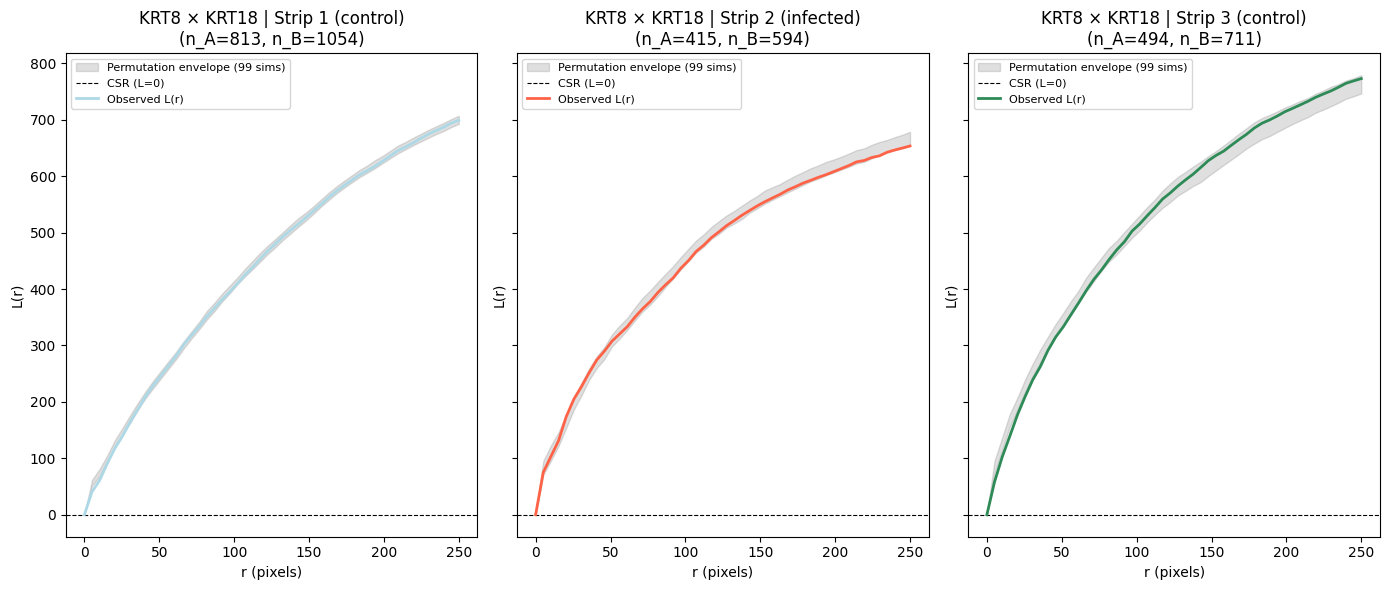

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)

strip_labels = {
    'strip_1': 'Strip 1 (control)',
    'strip_2': 'Strip 2 (infected)',
    'strip_3': 'Strip 3 (control)',
}
strip_colors = {
    'strip_1': 'lightblue',
    'strip_2': 'tomato',
    'strip_3': 'seagreen',
}

for ax, strip_name in zip(axes, ['strip_1', 'strip_2', 'strip_3']):
    res = results[strip_name]
    
    # Envelope (shaded region = range of null simulations)
    ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                    alpha=0.25, color='grey', label='Permutation envelope (99 sims)')
    
    # CSR baseline
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR (L=0)')
    
    # Observed
    ax.plot(r_vals, res['l_obs'], color=strip_colors[strip_name],
            linewidth=2, label=f'Observed L(r)')
    
    ax.set_xlabel('r (pixels)')
    ax.set_ylabel('L(r)')
    ax.set_title(f"{GENE_A} × {GENE_B} | {strip_labels[strip_name]}\n"
                 f"(n_A={res['n_a']}, n_B={res['n_b']})")
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/07_Expanded_Lfunction_' + GENE_A + '_' + GENE_B + '_by_strip.png', dpi=150, bbox_inches='tight')
plt.show()

  KRT8: 813 transcripts
  CD68: 112 transcripts
  Narrowest dimension: 4451 px
  R_MAX = 250 px (6% of narrow dim)
  Observed L(r) computed in 0.0s
    L(r=50): 250.35
    L(r=100): 423.50
    L(r=200): 629.69
  Envelope computed in 2.0s

Completed analysis for strip_1
----------------------------------------

  KRT8: 415 transcripts
  CD68: 60 transcripts
  Narrowest dimension: 3747 px
  R_MAX = 250 px (7% of narrow dim)
  Observed L(r) computed in 0.0s
    L(r=50): 296.79
    L(r=100): 459.22
    L(r=200): 600.21
  Envelope computed in 0.6s

Completed analysis for strip_2
----------------------------------------

  KRT8: 494 transcripts
  CD68: 69 transcripts
  Narrowest dimension: 4979 px
  R_MAX = 250 px (5% of narrow dim)
  Observed L(r) computed in 0.0s
    L(r=50): 298.56
    L(r=100): 492.87
    L(r=200): 700.71
  Envelope computed in 0.8s

Completed analysis for strip_3
----------------------------------------



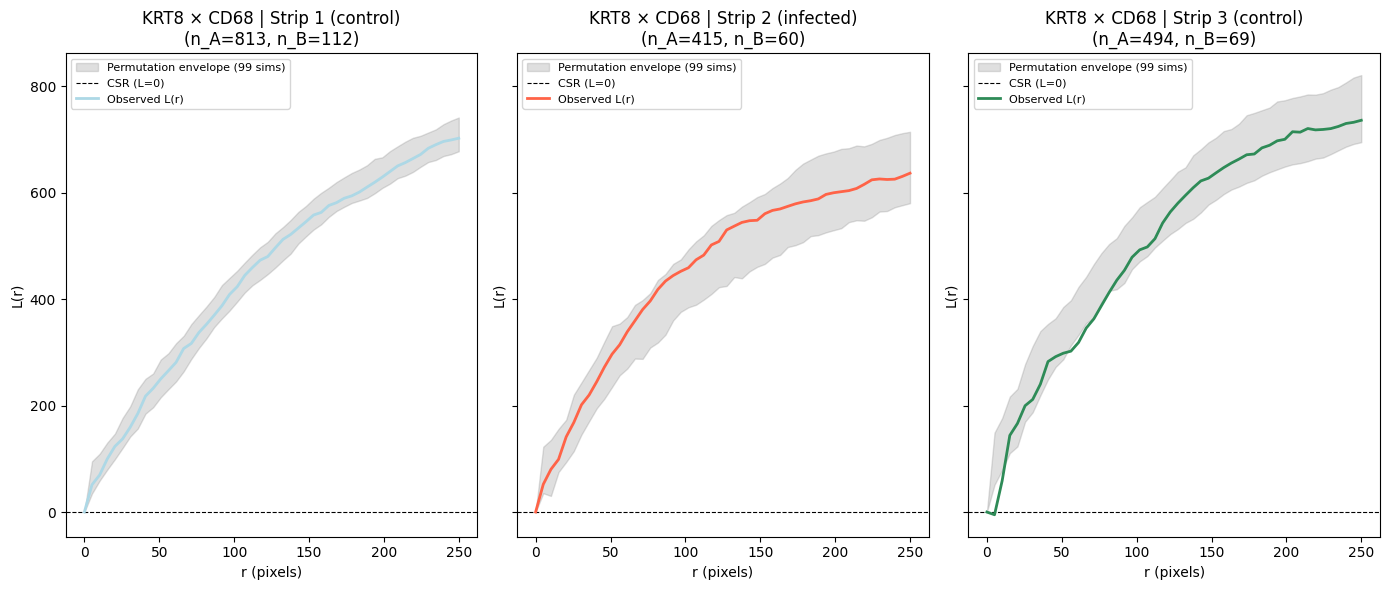

In [30]:
GENE_A = 'KRT8'
GENE_B = 'CD68'
R_MAX = 250           
N_R = 50             
N_SIM = 99          
SEED = 42

r_vals = np.linspace(0, R_MAX, N_R)

results = {}

for strip_name in ['strip_1', 'strip_2', 'strip_3']:
    strip_df = expanded_data[expanded_data['strip'] == strip_name]
    results[strip_name] = run_pair_analysis(strip_df, GENE_A, GENE_B, r_vals, 
                               strip_name=strip_name, diagnostics=False)
    print(f"\nCompleted analysis for {strip_name}\n{'-'*40}\n")

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)

strip_labels = {
    'strip_1': 'Strip 1 (control)',
    'strip_2': 'Strip 2 (infected)',
    'strip_3': 'Strip 3 (control)',
}
strip_colors = {
    'strip_1': 'lightblue',
    'strip_2': 'tomato',
    'strip_3': 'seagreen',
}

for ax, strip_name in zip(axes, ['strip_1', 'strip_2', 'strip_3']):
    res = results[strip_name]
    
    # Envelope (shaded region = range of null simulations)
    ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                    alpha=0.25, color='grey', label='Permutation envelope (99 sims)')
    
    # CSR baseline
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR (L=0)')
    
    # Observed
    ax.plot(r_vals, res['l_obs'], color=strip_colors[strip_name],
            linewidth=2, label=f'Observed L(r)')
    
    ax.set_xlabel('r (pixels)')
    ax.set_ylabel('L(r)')
    ax.set_title(f"{GENE_A} × {GENE_B} | {strip_labels[strip_name]}\n"
                 f"(n_A={res['n_a']}, n_B={res['n_b']})")
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/07_Expanded_Lfunction_' + GENE_A + '_' + GENE_B + '_by_strip.png', dpi=150, bbox_inches='tight')
plt.show()

SYNTHETIC VALIDATION RESULTS

Test 1: Co-clustered genes (positive)
  Prediction: L(r) >> 0, exceeds envelope above r ≈ 0
  Prediction: transition/plateau near r = 100px
  L(r=100):  98.51  (envelope: 87.62 – 96.19)
  L(r=200): 150.32  (envelope: 139.61 – 149.14)
  r values exceeding envelope: 34/50

Test 2: Clustered A, random B (negative control)
  Prediction: L(r) inside envelope at all r
  r values above envelope: 0/50  (expect 0)
  r values below envelope: 47/50  (expect 0)

Test 3: CSR baseline
  Prediction: max |L(r)| < 13
  Max |L(r)|: 3.983


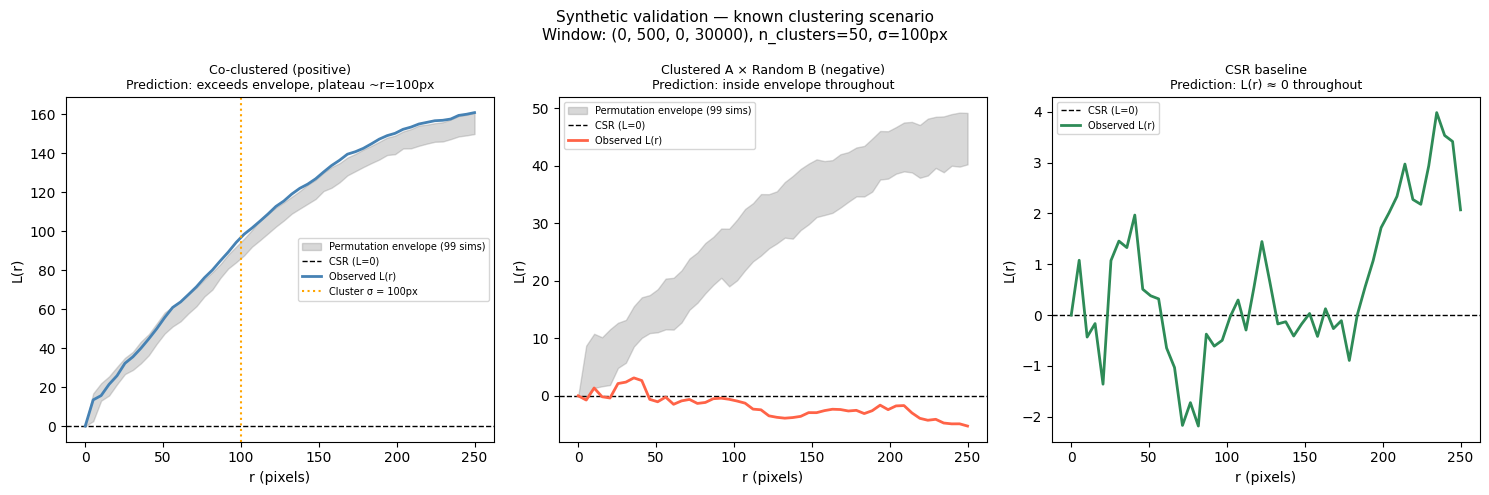

In [32]:
# ── Synthetic validation: known clustering scenario ───────────────────────
# 
# Design: place n_clusters clusters randomly in a strip-shaped window.
# Each cluster contains both gene A and gene B transcripts drawn from 
# a 2D Gaussian centred on the cluster location (sigma = CLUSTER_SIGMA).
# 
# Predictions we can make:
# 1. L(r) should rise sharply for r < CLUSTER_SIGMA (within-cluster)
# 2. L(r) should flatten/plateau for r >> CLUSTER_SIGMA (between-cluster)
# 3. The transition scale should match CLUSTER_SIGMA
# 4. A negative control (gene A from clusters, gene B random) should
#    sit inside the permutation envelope
# 5. CSR test (both genes random) should give L(r) ≈ 0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ── Parameters mirroring your data ───────────────────────────────────────
WINDOW = (0, 500, 0, 30000)       # strip-shaped, matches your geometry
N_CLUSTERS = 50                    # enough to give stable K estimates
N_PER_CLUSTER = 10                 # transcripts per gene per cluster
CLUSTER_SIGMA = 100                # px — sub-cellular to cell scale
                                   # prediction: L(r) transitions near r=100
N_RANDOM = 500                     # for negative control gene B
R_MAX = 250
N_R = 50
N_SIM = 99

x_min, x_max, y_min, y_max = WINDOW
r_vals = np.linspace(0, R_MAX, N_R)

# ── Generate cluster centres ──────────────────────────────────────────────
centres_x = rng.uniform(x_min, x_max, N_CLUSTERS)
centres_y = rng.uniform(y_min, y_max, N_CLUSTERS)

def make_clustered(centres_x, centres_y, n_per_cluster, sigma, window, rng):
    """Generate transcript coords from Gaussian clusters, clipped to window."""
    x_min, x_max, y_min, y_max = window
    points = []
    for cx, cy in zip(centres_x, centres_y):
        x = rng.normal(cx, sigma, n_per_cluster)
        y = rng.normal(cy, sigma, n_per_cluster)
        # Clip to window — mimics transcripts being inside tissue
        x = np.clip(x, x_min, x_max)
        y = np.clip(y, y_min, y_max)
        points.append(np.column_stack([x, y]))
    return np.vstack(points)

# ── Test 1: Both genes clustered together ─────────────────────────────────
# Prediction: strong co-localisation, L(r) >> 0, exceeds envelope
# Transition scale should be near CLUSTER_SIGMA = 100px
coords_a_clust = make_clustered(centres_x, centres_y, N_PER_CLUSTER, 
                                 CLUSTER_SIGMA, WINDOW, rng)
coords_b_clust = make_clustered(centres_x, centres_y, N_PER_CLUSTER, 
                                 CLUSTER_SIGMA, WINDOW, rng)

k_clust = bivariate_k(coords_a_clust, coords_b_clust, r_vals, WINDOW)
l_clust = k_to_l(k_clust, r_vals)
l_lo_clust, l_hi_clust = compute_envelope(coords_a_clust, coords_b_clust,
                                           r_vals, WINDOW, N_SIM)

# ── Test 2: Gene A clustered, gene B random (negative control) ────────────
# Prediction: L(r) inside envelope — no specific co-localisation
coords_b_rand = np.column_stack([
    rng.uniform(x_min, x_max, N_RANDOM),
    rng.uniform(y_min, y_max, N_RANDOM)
])

k_neg = bivariate_k(coords_a_clust, coords_b_rand, r_vals, WINDOW)
l_neg = k_to_l(k_neg, r_vals)
l_lo_neg, l_hi_neg = compute_envelope(coords_a_clust, coords_b_rand,
                                       r_vals, WINDOW, N_SIM)

# ── Test 3: CSR baseline ──────────────────────────────────────────────────
# Prediction: L(r) ≈ 0, max |L(r)| < 13 (from your prior validation)
coords_a_csr = np.column_stack([
    rng.uniform(x_min, x_max, N_CLUSTERS * N_PER_CLUSTER),
    rng.uniform(y_min, y_max, N_CLUSTERS * N_PER_CLUSTER)
])
coords_b_csr = np.column_stack([
    rng.uniform(x_min, x_max, N_CLUSTERS * N_PER_CLUSTER),
    rng.uniform(y_min, y_max, N_CLUSTERS * N_PER_CLUSTER)
])

k_csr = bivariate_k(coords_a_csr, coords_b_csr, r_vals, WINDOW)
l_csr = k_to_l(k_csr, r_vals)

# ── Print predictions vs results ──────────────────────────────────────────
print("=" * 60)
print("SYNTHETIC VALIDATION RESULTS")
print("=" * 60)

print("\nTest 1: Co-clustered genes (positive)")
print(f"  Prediction: L(r) >> 0, exceeds envelope above r ≈ 0")
print(f"  Prediction: transition/plateau near r = {CLUSTER_SIGMA}px")
idx_sigma = np.argmin(np.abs(r_vals - CLUSTER_SIGMA))
idx_2sigma = np.argmin(np.abs(r_vals - 2 * CLUSTER_SIGMA))
print(f"  L(r={CLUSTER_SIGMA:.0f}):  {l_clust[idx_sigma]:.2f}  "
      f"(envelope: {l_lo_clust[idx_sigma]:.2f} – {l_hi_clust[idx_sigma]:.2f})")
print(f"  L(r={2*CLUSTER_SIGMA:.0f}): {l_clust[idx_2sigma]:.2f}  "
      f"(envelope: {l_lo_clust[idx_2sigma]:.2f} – {l_hi_clust[idx_2sigma]:.2f})")
above_envelope = np.sum(l_clust > l_hi_clust)
print(f"  r values exceeding envelope: {above_envelope}/{N_R}")

print("\nTest 2: Clustered A, random B (negative control)")
print(f"  Prediction: L(r) inside envelope at all r")
above_neg = np.sum(l_neg > l_hi_neg)
below_neg = np.sum(l_neg < l_lo_neg)
print(f"  r values above envelope: {above_neg}/{N_R}  (expect 0)")
print(f"  r values below envelope: {below_neg}/{N_R}  (expect 0)")

print("\nTest 3: CSR baseline")
print(f"  Prediction: max |L(r)| < 13")
print(f"  Max |L(r)|: {np.abs(l_csr).max():.3f}")

# ── Plot all three ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

tests = [
    (l_clust, l_lo_clust, l_hi_clust, 
     'Co-clustered (positive)', 'steelblue',
     f'Prediction: exceeds envelope, plateau ~r={CLUSTER_SIGMA}px'),
    (l_neg, l_lo_neg, l_hi_neg,
     'Clustered A × Random B (negative)', 'tomato',
     'Prediction: inside envelope throughout'),
    (l_csr, None, None,
     'CSR baseline', 'seagreen',
     'Prediction: L(r) ≈ 0 throughout'),
]

for ax, (l_obs, l_lo, l_hi, title, color, prediction) in zip(axes, tests):
    if l_lo is not None:
        ax.fill_between(r_vals, l_lo, l_hi, alpha=0.3, color='grey',
                        label='Permutation envelope (99 sims)')
    ax.axhline(0, color='black', linestyle='--', linewidth=1, label='CSR (L=0)')
    ax.plot(r_vals, l_obs, color=color, linewidth=2, label='Observed L(r)')
    if title == 'Co-clustered (positive)':
        ax.axvline(CLUSTER_SIGMA, color='orange', linestyle=':', linewidth=1.5,
                   label=f'Cluster σ = {CLUSTER_SIGMA}px')
    ax.set_xlabel('r (pixels)')
    ax.set_ylabel('L(r)')
    ax.set_title(f'{title}\n{prediction}', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Synthetic validation — known clustering scenario\n'
             f'Window: {WINDOW}, n_clusters={N_CLUSTERS}, σ={CLUSTER_SIGMA}px',
             fontsize=11)
plt.tight_layout()
plt.show()